In [4]:
# ============================================
# SpectraGuard - RF Modulation Classification
# Cell 1: Imports and Device Setup
# ============================================

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
GPU count: 2


In [5]:
# ============================================
# SpectraGuard - RF Modulation Classification
# Cell 2: Dataset Configuration
# ============================================

DATA_PATH = "/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5"

# RadioML 2018.01A - verified class mapping
CLASS_NAMES = [
    'OOK',
    '4ASK',
    '8ASK',
    'BPSK',
    'QPSK',
    '8PSK',
    '16PSK',
    '32PSK',
    '16APSK',
    '32APSK',
    '64APSK',
    '128APSK',
    '16QAM',
    '32QAM',
    '64QAM',
    '128QAM',
    '256QAM',
    'AM-SSB-WC',
    'AM-SSB-SC',
    'AM-DSB-WC',
    'AM-DSB-SC',
    'FM',
    'GMSK',
    'OQPSK'
]

NUM_CLASSES = len(CLASS_NAMES)

# SNR levels for our first pilot experiment
SNR_LEVELS = [-20, -10, 0, 10, 20]

# Number of examples per class per SNR
SAMPLES_PER_CLASS_PER_SNR = 300

print("Dataset:", DATA_PATH)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)
print("SNR levels:", SNR_LEVELS)
print("Samples per class/SNR:", SAMPLES_PER_CLASS_PER_SNR)

Dataset: /kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
Number of classes: 24
Classes: ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
SNR levels: [-20, -10, 0, 10, 20]
Samples per class/SNR: 300


In [6]:
# ============================================
# SpectraGuard - RF Modulation Classification
# Cell 3: Load Pilot RF/IQ Dataset
# ============================================

X_list = []
y_list = []
snr_list = []

with h5py.File(DATA_PATH, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    for snr in SNR_LEVELS:
        print(f"Loading SNR = {snr} dB")

        # Find indices belonging to this SNR
        snr_indices = np.where(Z[:, 0] == snr)[0]

        # Process each modulation class separately
        for class_idx in range(NUM_CLASSES):

            # Get class labels for this SNR
            labels = np.argmax(Y[snr_indices], axis=1)

            class_indices = snr_indices[labels == class_idx]

            # Select the first 300 samples
            selected_indices = class_indices[:SAMPLES_PER_CLASS_PER_SNR]

            # Read only these samples from HDF5
            X_list.append(X[selected_indices])

            # Store corresponding labels
            y_list.extend([class_idx] * len(selected_indices))

            # Store corresponding SNR
            snr_list.extend([snr] * len(selected_indices))

# Combine everything
X_pilot = np.concatenate(X_list, axis=0)
y_pilot = np.array(y_list, dtype=np.int64)
snr_pilot = np.array(snr_list, dtype=np.int64)

print("\n============================================")
print("Pilot dataset loaded successfully!")
print("============================================")
print("X shape   :", X_pilot.shape)
print("y shape   :", y_pilot.shape)
print("SNR shape :", snr_pilot.shape)
print("Memory    :", round(X_pilot.nbytes / (1024**2), 2), "MB")

Loading SNR = -20 dB
Loading SNR = -10 dB
Loading SNR = 0 dB
Loading SNR = 10 dB
Loading SNR = 20 dB

Pilot dataset loaded successfully!
X shape   : (36000, 1024, 2)
y shape   : (36000,)
SNR shape : (36000,)
Memory    : 281.25 MB


Total samples: 36000
Number of classes: 24

Class distribution:
 0 - OOK         : 1500
 1 - 4ASK        : 1500
 2 - 8ASK        : 1500
 3 - BPSK        : 1500
 4 - QPSK        : 1500
 5 - 8PSK        : 1500
 6 - 16PSK       : 1500
 7 - 32PSK       : 1500
 8 - 16APSK      : 1500
 9 - 32APSK      : 1500
10 - 64APSK      : 1500
11 - 128APSK     : 1500
12 - 16QAM       : 1500
13 - 32QAM       : 1500
14 - 64QAM       : 1500
15 - 128QAM      : 1500
16 - 256QAM      : 1500
17 - AM-SSB-WC   : 1500
18 - AM-SSB-SC   : 1500
19 - AM-DSB-WC   : 1500
20 - AM-DSB-SC   : 1500
21 - FM          : 1500
22 - GMSK        : 1500
23 - OQPSK       : 1500

SNR distribution:
-20 dB : 7200
-10 dB : 7200
  0 dB : 7200
 10 dB : 7200
 20 dB : 7200

Sample statistics:
Minimum : -25.295225
Maximum : 29.499447
Mean    : -0.004281925
Std     : 1.3751048

Example sample:
Class: OOK
SNR  : -20 dB


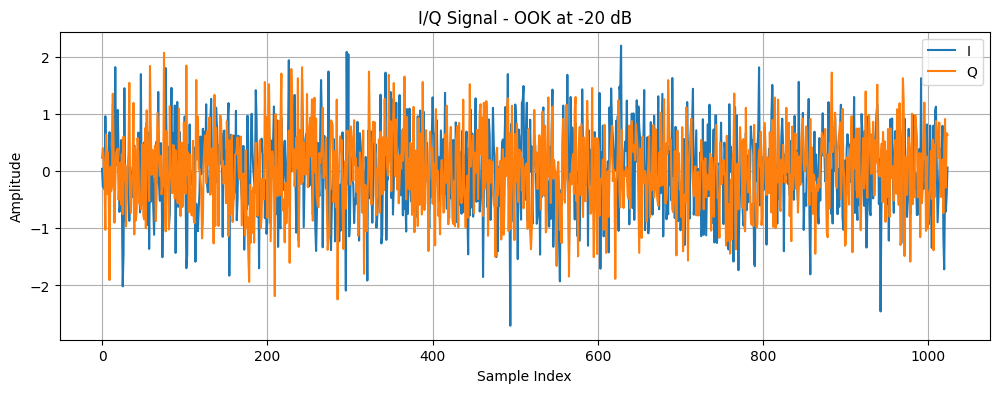

In [7]:
# ============================================
# SpectraGuard - Cell 4
# Dataset Verification & IQ Visualization
# ============================================

print("Total samples:", len(X_pilot))
print("Number of classes:", NUM_CLASSES)

# --------------------------------------------
# 1. Class distribution
# --------------------------------------------
unique_classes, class_counts = np.unique(y_pilot, return_counts=True)

print("\nClass distribution:")
for cls, count in zip(unique_classes, class_counts):
    print(f"{cls:2d} - {CLASS_NAMES[cls]:12s}: {count}")

# --------------------------------------------
# 2. SNR distribution
# --------------------------------------------
unique_snr, snr_counts = np.unique(snr_pilot, return_counts=True)

print("\nSNR distribution:")
for snr, count in zip(unique_snr, snr_counts):
    print(f"{snr:3d} dB : {count}")

# --------------------------------------------
# 3. Check sample values
# --------------------------------------------
print("\nSample statistics:")
print("Minimum :", X_pilot.min())
print("Maximum :", X_pilot.max())
print("Mean    :", X_pilot.mean())
print("Std     :", X_pilot.std())

# --------------------------------------------
# 4. Visualize one IQ sample
# --------------------------------------------
sample_idx = 0

I = X_pilot[sample_idx, :, 0]
Q = X_pilot[sample_idx, :, 1]

print("\nExample sample:")
print("Class:", CLASS_NAMES[y_pilot[sample_idx]])
print("SNR  :", snr_pilot[sample_idx], "dB")

plt.figure(figsize=(12, 4))

plt.plot(I, label="I")
plt.plot(Q, label="Q")

plt.title(
    f"I/Q Signal - {CLASS_NAMES[y_pilot[sample_idx]]} "
    f"at {snr_pilot[sample_idx]} dB"
)

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ============================================
# SpectraGuard - Cell 5
# Train / Validation / Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Create a combined stratification label:
# modulation class + SNR
snr_to_index = {snr: i for i, snr in enumerate(SNR_LEVELS)}

stratify_labels = np.array([
    y_pilot[i] * len(SNR_LEVELS) + snr_to_index[snr_pilot[i]]
    for i in range(len(y_pilot))
])

# --------------------------------------------
# First split: 70% train, 30% temporary
# --------------------------------------------
X_train, X_temp, y_train, y_temp, snr_train, snr_temp = train_test_split(
    X_pilot,
    y_pilot,
    snr_pilot,
    test_size=0.30,
    random_state=42,
    stratify=stratify_labels
)

# --------------------------------------------
# Split temporary set into:
# 15% validation
# 15% test
# --------------------------------------------
temp_stratify = np.array([
    y_temp[i] * len(SNR_LEVELS) + snr_to_index[snr_temp[i]]
    for i in range(len(y_temp))
])

X_val, X_test, y_val, y_test, snr_val, snr_test = train_test_split(
    X_temp,
    y_temp,
    snr_temp,
    test_size=0.50,
    random_state=42,
    stratify=temp_stratify
)

print("============================================")
print("Dataset Split")
print("============================================")

print("\nTraining:")
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\nValidation:")
print("X_val   :", X_val.shape)
print("y_val   :", y_val.shape)

print("\nTesting:")
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

Dataset Split

Training:
X_train : (25200, 1024, 2)
y_train : (25200,)

Validation:
X_val   : (5400, 1024, 2)
y_val   : (5400,)

Testing:
X_test  : (5400, 1024, 2)
y_test  : (5400,)

Total: 36000


In [9]:
# ============================================
# SpectraGuard - Cell 6
# Prepare IQ Data for CNN
# ============================================

# Convert:
# (N, 1024, 2) → (N, 2, 1024)

X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_val_cnn   = np.transpose(X_val,   (0, 2, 1))
X_test_cnn  = np.transpose(X_test,  (0, 2, 1))

print("CNN input shapes:")
print("X_train_cnn :", X_train_cnn.shape)
print("X_val_cnn   :", X_val_cnn.shape)
print("X_test_cnn  :", X_test_cnn.shape)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_cnn, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_cnn, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_cnn, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

print("\nTensor shapes:")
print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Val  :", X_val_tensor.shape, y_val_tensor.shape)
print("Test :", X_test_tensor.shape, y_test_tensor.shape)

CNN input shapes:
X_train_cnn : (25200, 2, 1024)
X_val_cnn   : (5400, 2, 1024)
X_test_cnn  : (5400, 2, 1024)

Tensor shapes:
Train: torch.Size([25200, 2, 1024]) torch.Size([25200])
Val  : torch.Size([5400, 2, 1024]) torch.Size([5400])
Test : torch.Size([5400, 2, 1024]) torch.Size([5400])


In [10]:
# ============================================
# SpectraGuard - Cell 7
# PyTorch Dataset & DataLoaders
# ============================================

from torch.utils.data import TensorDataset, DataLoader

# Create PyTorch datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Batch size
BATCH_SIZE = 256

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("============================================")
print("DataLoaders created successfully")
print("============================================")

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

# Check one batch
sample_batch, label_batch = next(iter(train_loader))

print("\nOne training batch:")
print("Input shape :", sample_batch.shape)
print("Label shape :", label_batch.shape)
print("Device      :", sample_batch.device)

DataLoaders created successfully
Batch size: 256
Training batches: 99
Validation batches: 22
Testing batches: 22

One training batch:
Input shape : torch.Size([256, 2, 1024])
Label shape : torch.Size([256])
Device      : cpu


In [11]:
# ============================================
# SpectraGuard - Cell 8
# CNN Baseline Model
# ============================================

class SpectraCNN(nn.Module):

    def __init__(self, num_classes=24):
        super(SpectraCNN, self).__init__()

        # Feature extraction
        self.features = nn.Sequential(

            # Block 1
            nn.Conv1d(
                in_channels=2,
                out_channels=64,
                kernel_size=7,
                padding=3
            ),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 2
            nn.Conv1d(
                in_channels=64,
                out_channels=128,
                kernel_size=5,
                padding=2
            ),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 3
            nn.Conv1d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Global pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Classification layer
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = x.squeeze(-1)

        x = self.classifier(x)

        return x


# Create model
model = SpectraCNN(num_classes=NUM_CLASSES)

# Move model to GPU
model = model.to(device)

print(model)

# Count trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal trainable parameters:", f"{total_params:,}")
print("Model device:", next(model.parameters()).device)

SpectraCNN(
  (features): Sequential(
    (0): Conv1d(2, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Linear(in_features=256, out_features=24, bias=True)
)

Total trainable parameters: 147,672
Model device: cuda:0


In [12]:
# ============================================
# SpectraGuard - Cell 9
# Loss Function & Optimizer
# ============================================

# Loss function for 24-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of training epochs
NUM_EPOCHS = 10

print("============================================")
print("Training configuration")
print("============================================")

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", 0.001)
print("Epochs        :", NUM_EPOCHS)
print("Device        :", device)

Training configuration
Loss function : CrossEntropyLoss()
Optimizer     : Adam
Learning rate : 0.001
Epochs        : 10
Device        : cuda


In [13]:
# ============================================
# SpectraGuard - Cell 10
# CNN Training & Validation
# ============================================

import time

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================
    # TRAINING
    # ========================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        # Move batch to GPU
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_accuracy = 100 * correct / total

    # ========================================
    # VALIDATION
    # ========================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / val_total
    epoch_val_accuracy = 100 * val_correct / val_total

    # Store history
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    # ========================================
    # SAVE BEST MODEL
    # ========================================

    if epoch_val_accuracy > best_val_accuracy:

        best_val_accuracy = epoch_val_accuracy

        torch.save(
            model.state_dict(),
            "spectraguard_cnn_best.pth"
        )

        best_marker = "  ← BEST"

    else:
        best_marker = ""

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.2f}% | "
        f"Time: {elapsed:.1f}s"
        f"{best_marker}"
    )

print("\n============================================")
print("Training completed!")
print("============================================")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print("Best model saved as: spectraguard_cnn_best.pth")

Epoch [01/10] | Train Loss: 2.8073 | Train Acc: 14.77% | Val Loss: 2.5957 | Val Acc: 17.09% | Time: 5.8s  ← BEST
Epoch [02/10] | Train Loss: 2.4060 | Train Acc: 23.61% | Val Loss: 2.3317 | Val Acc: 26.07% | Time: 4.5s  ← BEST
Epoch [03/10] | Train Loss: 2.2465 | Train Acc: 27.16% | Val Loss: 2.2948 | Val Acc: 26.41% | Time: 4.6s  ← BEST
Epoch [04/10] | Train Loss: 2.1708 | Train Acc: 28.55% | Val Loss: 2.2035 | Val Acc: 27.94% | Time: 4.6s  ← BEST
Epoch [05/10] | Train Loss: 2.1275 | Train Acc: 29.31% | Val Loss: 2.1754 | Val Acc: 27.41% | Time: 4.6s
Epoch [06/10] | Train Loss: 2.0917 | Train Acc: 30.60% | Val Loss: 2.1271 | Val Acc: 30.59% | Time: 4.6s  ← BEST
Epoch [07/10] | Train Loss: 2.0726 | Train Acc: 30.92% | Val Loss: 2.2154 | Val Acc: 29.83% | Time: 4.6s
Epoch [08/10] | Train Loss: 2.0623 | Train Acc: 31.50% | Val Loss: 2.1657 | Val Acc: 31.94% | Time: 4.6s  ← BEST
Epoch [09/10] | Train Loss: 2.0461 | Train Acc: 32.08% | Val Loss: 2.0771 | Val Acc: 31.02% | Time: 4.7s
Epoch [

In [14]:
# ============================================
# SpectraGuard - Cell 11
# Test Best CNN Model
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load best validation model
model.load_state_dict(
    torch.load(
        "spectraguard_cnn_best.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(inputs)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# Convert to NumPy
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Calculate metrics
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print("============================================")
print("CNN Test Results")
print("============================================")

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision     : {test_precision * 100:.2f}%")
print(f"Recall        : {test_recall * 100:.2f}%")
print(f"F1 Score     : {test_f1 * 100:.2f}%")

CNN Test Results
Test Accuracy : 31.54%
Precision     : 39.45%
Recall        : 31.54%
F1 Score     : 31.37%


In [15]:
# ============================================
# CNN Evaluation - Classification Report
# ============================================

print("============================================")
print("CNN Classification Report")
print("============================================")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

CNN Classification Report
              precision    recall  f1-score   support

         OOK     0.4005    0.6711    0.5017       225
        4ASK     0.6710    0.4622    0.5474       225
        8ASK     0.8317    0.3733    0.5153       225
        BPSK     0.8544    0.6000    0.7050       225
        QPSK     0.6373    0.2889    0.3976       225
        8PSK     0.0000    0.0000    0.0000       225
       16PSK     0.2792    0.4356    0.3403       225
       32PSK     0.0000    0.0000    0.0000       225
      16APSK     0.6162    0.2711    0.3765       225
      32APSK     0.0866    0.5867    0.1509       225
      64APSK     0.1000    0.0800    0.0889       225
     128APSK     0.1226    0.4178    0.1895       225
       16QAM     0.0000    0.0000    0.0000       225
       32QAM     0.0000    0.0000    0.0000       225
       64QAM     0.0000    0.0000    0.0000       225
      128QAM     0.0000    0.0000    0.0000       225
      256QAM     0.0000    0.0000    0.0000       225
 

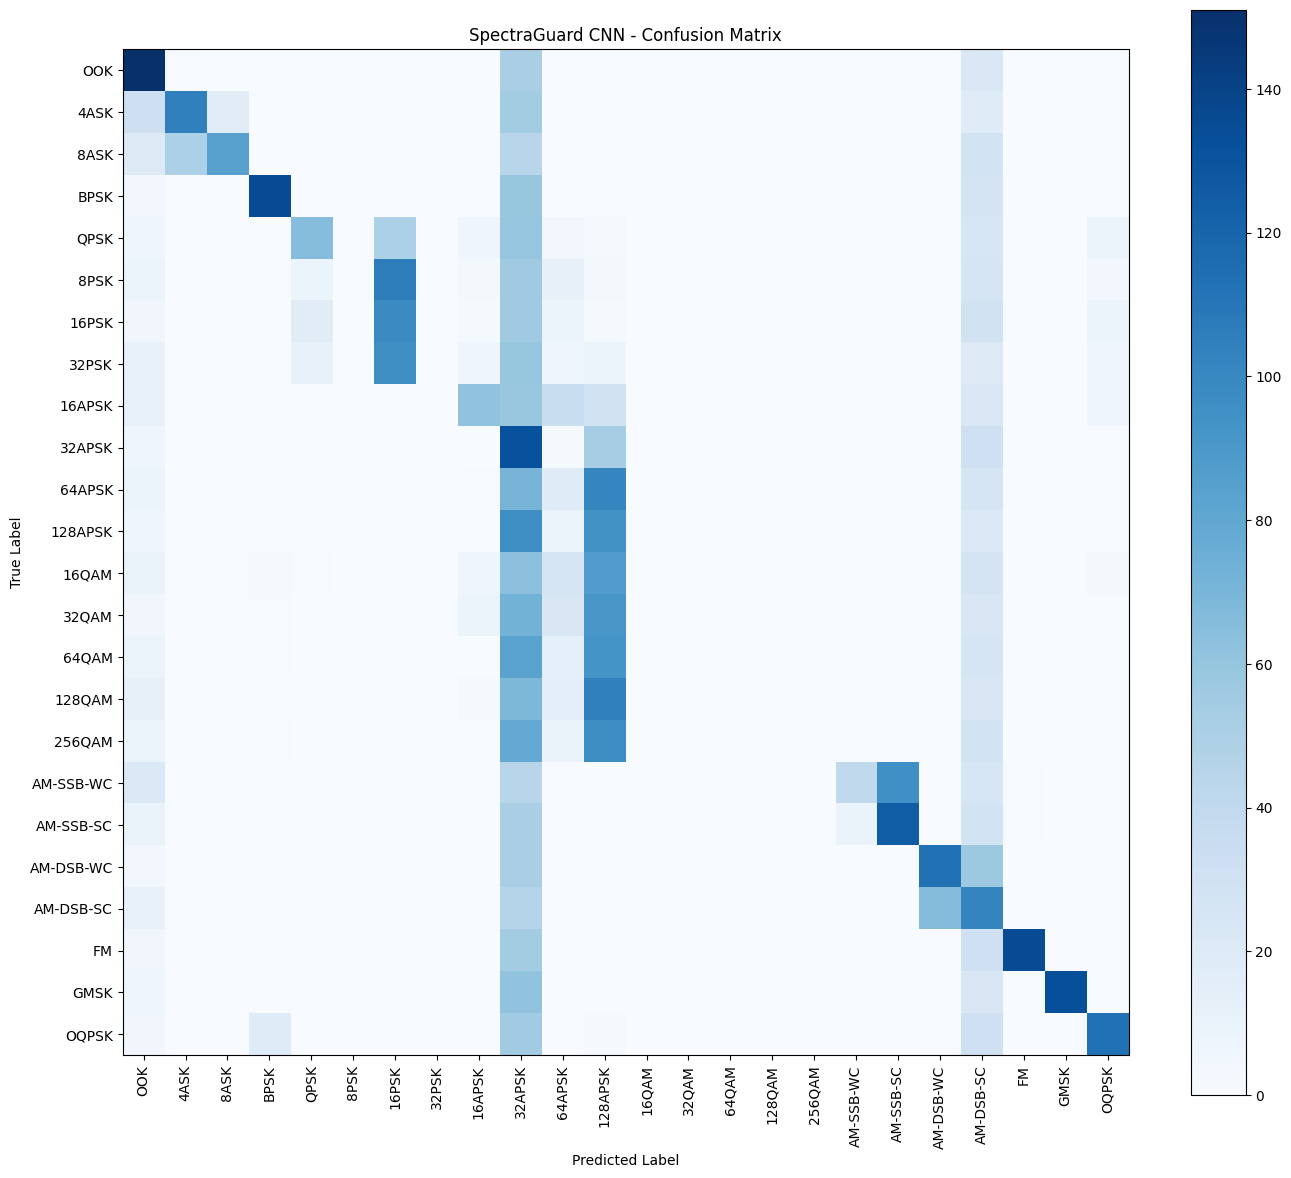

In [16]:
# ============================================
# CNN Evaluation - Confusion Matrix
# ============================================

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(14, 12))

plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar()

plt.xticks(
    np.arange(NUM_CLASSES),
    CLASS_NAMES,
    rotation=90
)

plt.yticks(
    np.arange(NUM_CLASSES),
    CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SpectraGuard CNN - Confusion Matrix")

plt.tight_layout()
plt.show()

CNN Accuracy by SNR
SNR -20 dB : 3.70%
SNR -10 dB : 5.74%
SNR   0 dB : 39.72%
SNR  10 dB : 53.70%
SNR  20 dB : 54.81%


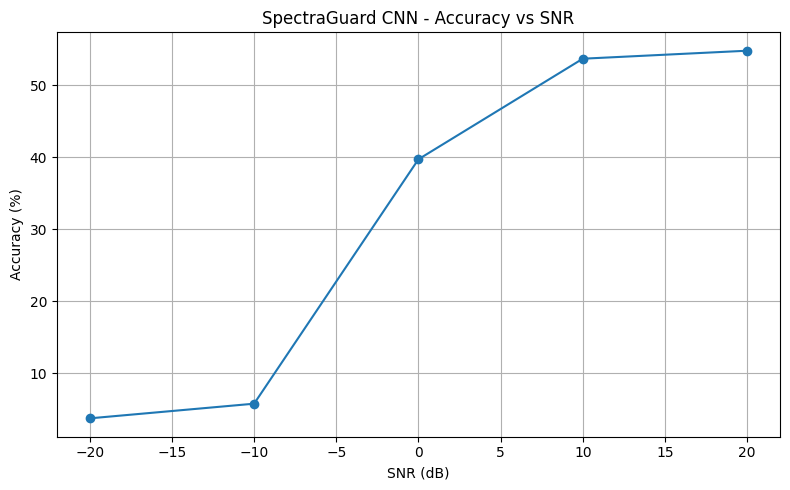

In [17]:
# ============================================
# CNN Evaluation - Accuracy by SNR
# ============================================

print("============================================")
print("CNN Accuracy by SNR")
print("============================================")

snr_values = sorted(np.unique(snr_test))
snr_accuracies = []

for snr in snr_values:
    mask = snr_test == snr
    
    snr_acc = accuracy_score(
        all_labels[mask],
        all_predictions[mask]
    )
    
    snr_accuracies.append(snr_acc)
    
    print(f"SNR {snr:>3} dB : {snr_acc * 100:.2f}%")

# Plot SNR-wise accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    snr_values,
    np.array(snr_accuracies) * 100,
    marker="o"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("SpectraGuard CNN - Accuracy vs SNR")
plt.grid(True)
plt.tight_layout()
plt.show()